# EDA 4 — Boundary Effects: London-Only vs National Frame

**Purpose:** Quantify how including London-external flows (via the +1 synthetic MSOA) changes the cascade-counter balance, and whether this alters the typology or its validation.

### Three questions
1. **Where do external flows land?** How external volumes distribute across the decile hierarchy, and why ~69% of London MSOAs receive them as "wealthier" connections.
2. **What shifts in the cascade-counter balance?** Per-MSOA and per-decile dominance shifts between London-only and national frames.
3. **Does the typology change?** Compute missing national-frame derived metrics, re-classify, and compare.

### Data source
`msoa_cascade_national_frame_20260623.csv`: 983 London MSOAs with both London-only (`_11`/`_21`) and national-frame (`_nat_11`/`_nat_21`) cascade metrics.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path
from pyprojroot import here

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

# ── Paths ────────────────────────
ROOT = here()
DATA_DIR = ROOT / 'outputs'
OUTPUT_DIR = ROOT / 'outputs/eda_figs'
GEO_PATH = ROOT / 'data/london_msoa_2011.geojson'


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# ── Load data ─────────────────────────────────────────────────
df = pd.read_csv(DATA_DIR / 'msoa_cascade_national_frame_20260623.csv')
print(f'Loaded: {df.shape[0]} MSOAs, {df.shape[1]} columns')

# Quick check: national columns present
nat_cols = [c for c in df.columns if '_nat_' in c]
print(f'National-frame columns: {len(nat_cols)}')

Loaded: 983 MSOAs, 98 columns
National-frame columns: 36


---
## 1. Compute Missing National-Frame Derived Metrics

The preprocessing exported base metrics and `Cascade_Dominance_nat`, but not:
- `Cross_Decile_Share_nat` — share of migration crossing decile boundaries among all migration records.
- `Sign_Concordance_nat` — whether Net_Cascade and Net_Counter share the same sign.

We compute these here using the same formulas as EDA 1.

In [3]:
# ── Cross_Decile_Share_nat ────────────────────────────────────
# Formula: (CFI_Churn + Counter_Churn) / Total_Migration
df = df.copy()

for yr in ['11', '21']:
    cfi  = df[f'CFI_Churn_nat_{yr}']
    cc   = df[f'Counter_Churn_nat_{yr}']
    tmig = df[f'Total_Migration_nat_{yr}']
    df[f'Cross_Decile_Share_nat_{yr}'] = np.where(
        tmig > 0, (cfi + cc) / tmig, 0)

# ── Sign_Concordance_nat ──────────────────────────────────────
for yr in ['11', '21']:
    nc  = df[f'Net_Cascade_nat_{yr}']
    ncc = df[f'Net_Counter_nat_{yr}']
    df[f'Sign_Concordance_nat_{yr}'] = np.where(
        (nc == 0) | (ncc == 0), 'zero',
        np.where(np.sign(nc) == np.sign(ncc), 'concordant', 'divergent')
    )

# ── Verify ────────────────────────────────────────────────────
print('=== Cross_Decile_Share_nat (2011) ===')
print(df['Cross_Decile_Share_nat_11'].describe().round(4).to_string())
print(f'\n=== Sign_Concordance_nat (2011) ===')
print(df['Sign_Concordance_nat_11'].value_counts().to_string())

print(f'\n=== Cross_Decile_Share_nat (2021) ===')
print(df['Cross_Decile_Share_nat_21'].describe().round(4).to_string())
print(f'\n=== Sign_Concordance_nat (2021) ===')
print(df['Sign_Concordance_nat_21'].value_counts().to_string())

=== Cross_Decile_Share_nat (2011) ===
count    983.0000
mean       0.8227
std        0.1031
min        0.5183
25%        0.7522
50%        0.8429
75%        0.9055
max        0.9957

=== Sign_Concordance_nat (2011) ===
Sign_Concordance_nat_11
concordant    904
divergent      78
zero            1

=== Cross_Decile_Share_nat (2021) ===
count    983.0000
mean       0.8231
std        0.1544
min        0.0000
25%        0.7805
50%        0.8588
75%        0.9148
max        0.9991

=== Sign_Concordance_nat (2021) ===
Sign_Concordance_nat_21
concordant    841
divergent     120
zero           22


### Interpretation:

- Count of 983, not 984, has been explained in data preprocess 20260622 file.

> Why the 2021 `Cross_Decile_Share_nat`(2021) has min = 0?


- The count of "Zero" of `Sign_Concordance_nat` jumped from 1 in 2011 to 22 in 2021. 
> This is consistent with "Zero" analysis in London-only version?
> - In London-only analysis, there were 2 "Zero" in 2011 and 21 in 2021. Are they the same in the national-frame analysis? If not, what have been changed?
> - Not just "Zero", other categories also changed in counts. Where are those changes in spatial distribution?
> **Check whether those 22 zero-concordance MSOAs line up with consistent 20 disclosure-suppressed MSOAs we found earlier (zero external flows in 2021) plus a couple of genuinely sparse areas, so can decide whether to flag or exclude them?**

In [4]:
# =====================================================================
# Compute Internal London flows, National deciles
# =====================================================================

# Three frames:
#   A = London-internal flows, London-relative deciles   (existing _11/_21 cols)
#   B = London-internal flows, NATIONAL deciles          (computed here)
#   C = London-internal + external flows, national deciles (existing _nat_ cols)
#
# Decomposition:
#   B - A = pure reclassification effect  (same flows, different decile ladder)
#   C - B = pure external flow effect     (same decile ladder, external flows added)
#   C - A = total difference              (what we currently show)
# =====================================================================
 
EXT_DECILE = 6   # synthetic external MSOA assigned D6

In [5]:
# ── Derive frame B by subtracting external-flow contributions from C ────────
# For MSOA with national decile d:
#   d < 6 → ext inflow = Inflow_Wealthier; ext outflow = Outflow_Wealthier
#   d > 6 → ext inflow = Inflow_Poorer;    ext outflow = Outflow_Poorer
#   d = 6 → ext flows are lateral (same decile, no cascade/counter effect)
 
nat_dec = df['Wealth_Decile_National']
 
for yr in ['11', '21']:
    ext_in  = df[f'Ext_Inflow_nat_{yr}'].fillna(0)
    ext_out = df[f'Ext_Outflow_nat_{yr}'].fillna(0)
 
    # How external flows are allocated to cascade/counter categories
    ext_to_iw = np.where(nat_dec < EXT_DECILE, ext_in, 0)   # Inflow_Wealthier
    ext_to_ip = np.where(nat_dec > EXT_DECILE, ext_in, 0)   # Inflow_Poorer
    ext_to_ow = np.where(nat_dec < EXT_DECILE, ext_out, 0)  # Outflow_Wealthier
    ext_to_op = np.where(nat_dec > EXT_DECILE, ext_out, 0)  # Outflow_Poorer
 
    # B = C minus external contribution (internal flows only, national deciles)
    df[f'Inflow_Wealthier_intnat_{yr}']  = df[f'Inflow_Wealthier_nat_{yr}'] - ext_to_iw
    df[f'Outflow_Poorer_intnat_{yr}']    = df[f'Outflow_Poorer_nat_{yr}']   - ext_to_op
    df[f'Outflow_Wealthier_intnat_{yr}'] = df[f'Outflow_Wealthier_nat_{yr}']- ext_to_ow
    df[f'Inflow_Poorer_intnat_{yr}']     = df[f'Inflow_Poorer_nat_{yr}']    - ext_to_ip
 
    # Derived B metrics
    df[f'CFI_Churn_intnat_{yr}']     = (df[f'Inflow_Wealthier_intnat_{yr}'] +
                                        df[f'Outflow_Poorer_intnat_{yr}'])
    df[f'Counter_Churn_intnat_{yr}'] = (df[f'Outflow_Wealthier_intnat_{yr}'] +
                                        df[f'Inflow_Poorer_intnat_{yr}'])
    df[f'Net_Cascade_intnat_{yr}']   = (df[f'Inflow_Wealthier_intnat_{yr}'] -
                                        df[f'Outflow_Poorer_intnat_{yr}'])
    df[f'Net_Counter_intnat_{yr}']   = (df[f'Outflow_Wealthier_intnat_{yr}'] -
                                        df[f'Inflow_Poorer_intnat_{yr}'])
 
    total_cross_b = df[f'CFI_Churn_intnat_{yr}'] + df[f'Counter_Churn_intnat_{yr}']
    df[f'Cascade_Dominance_intnat_{yr}'] = np.where(
        total_cross_b > 0, df[f'CFI_Churn_intnat_{yr}'] / total_cross_b, 0.5)
 
    # Total migration for B = C's total minus external
    df[f'Total_Migration_intnat_{yr}'] = (df[f'Total_Migration_nat_{yr}']
                                          - ext_in - ext_out)
 
    df[f'Cross_Decile_Share_intnat_{yr}'] = np.where(
        df[f'Total_Migration_intnat_{yr}'] > 0,
        total_cross_b / df[f'Total_Migration_intnat_{yr}'], 0)
    
# ── Sanity checks ─────────────────────────────────────────────────────
print('=' * 70)
print('Sanity Checks for splitting London and national frames (Step B)')
print('=' * 70)
 
for yr in ['11', '21']:
    # B's total migration should exactly match A's (same internal flows)
    diff = (df[f'Total_Migration_intnat_{yr}'] - df[f'Total_Migration_{yr}']).abs().max()
    # All B base flows should be non-negative
    neg_check = min(
        df[f'Inflow_Wealthier_intnat_{yr}'].min(),
        df[f'Outflow_Poorer_intnat_{yr}'].min(),
        df[f'Outflow_Wealthier_intnat_{yr}'].min(),
        df[f'Inflow_Poorer_intnat_{yr}'].min()
    )
    print(f'\n  20{yr}:')
    print(f'    Total_Migration B vs A max diff: {diff:.1f} (should be 0)')
    print(f'    Min base flow in B:              {neg_check:.0f} (should be >= 0)')
    print(f'    Mean Cascade_Dominance: A={df[f"Cascade_Dominance_{yr}"].mean():.4f}  '
          f'B={df[f"Cascade_Dominance_intnat_{yr}"].mean():.4f}  '
          f'C={df[f"Cascade_Dominance_nat_{yr}"].mean():.4f}')
 
print('\n step B computed. Suffix _intnat_ = internal flows, national deciles.')

Sanity Checks for splitting London and national frames (Step B)

  2011:
    Total_Migration B vs A max diff: 0.0 (should be 0)
    Min base flow in B:              0 (should be >= 0)
    Mean Cascade_Dominance: A=0.4798  B=0.4815  C=0.4863

  2021:
    Total_Migration B vs A max diff: 0.0 (should be 0)
    Min base flow in B:              0 (should be >= 0)
    Mean Cascade_Dominance: A=0.4638  B=0.4645  C=0.4555

 step B computed. Suffix _intnat_ = internal flows, national deciles.


In [9]:
# =====================================================================
# Diagnostic: CDS = 0 and zero-migration MSOAs
# =====================================================================
 
print('=' * 70)
print('DIAGNOSTIC: Zero Cross-Decile-Share / Zero-Migration MSOAs')
print('=' * 70)
 
for yr in ['11', '21']:
    cds_nat = df[f'Cross_Decile_Share_nat_{yr}']
    cds_ldn = df[f'Cross_Decile_Share_{yr}']
 
    nat_zero = set(df.loc[cds_nat == 0, 'msoa11cd'])
    ldn_zero = set(df.loc[cds_ldn == 0, 'msoa11cd'])
 
    print(f'\n  20{yr}:')
    print(f'    National CDS = 0: {len(nat_zero)} MSOAs')
    print(f'    London   CDS = 0: {len(ldn_zero)} MSOAs')
    print(f'    Identical set?    {nat_zero == ldn_zero}')
 
    if nat_zero:
        mask = df['msoa11cd'].isin(nat_zero)
        print(f'    All have Total_Mig_nat = 0?  '
              f'{(df.loc[mask, f"Total_Migration_nat_{yr}"] == 0).all()}')
        print(f'    All have Ext_Inflow = 0?      '
              f'{(df.loc[mask, f"Ext_Inflow_nat_{yr}"] == 0).all()}')
        print(f'These are disclosure-suppressed MSOAs with no migration '
              f'data in 2021. \nThey exist in BOTH frames identically.')

DIAGNOSTIC: Zero Cross-Decile-Share / Zero-Migration MSOAs

  2011:
    National CDS = 0: 0 MSOAs
    London   CDS = 0: 0 MSOAs
    Identical set?    True

  2021:
    National CDS = 0: 20 MSOAs
    London   CDS = 0: 20 MSOAs
    Identical set?    True
    All have Total_Mig_nat = 0?  True
    All have Ext_Inflow = 0?      True
These are disclosure-suppressed MSOAs with no migration data in 2021. 
They exist in BOTH frames identically.


---
# PART 1: Where Do External Flows Land?

External flows connect London MSOAs to the synthetic `EXT_OUTSIDE` MSOA (assigned national D6). Because ~69% of London MSOAs sit in national D1–D5, for those areas external inflows are `Inflow_Wealthier` and external outflows are `Outflow_Wealthier`.

This section quantifies:
- Aggregate external flow volumes (2011 vs 2021)
- How external inflows and outflows distribute across the decile hierarchy
- Which MSOAs receive the largest external flow injections

---

## 1a. Aggregate External Flow Summary

In [10]:
print('=' * 65)
print('AGGREGATE EXTERNAL FLOW SUMMARY')
print('=' * 65)

for yr in ['11', '21']:
    ei = df[f'Ext_Inflow_nat_{yr}']
    eo = df[f'Ext_Outflow_nat_{yr}']
    en = df[f'Ext_Net_nat_{yr}']
    
    print(f'\n── 20{yr} ──')
    print(f'  External inflows  (Ext→Ldn):  {ei.sum():>10,.0f} total, '
          f'{ei.mean():>6.1f} per MSOA')
    print(f'  External outflows (Ldn→Ext):  {eo.sum():>10,.0f} total, '
          f'{eo.mean():>6.1f} per MSOA')
    print(f'  Net external:                 {en.sum():>10,.0f} total, '
          f'{en.mean():>+6.1f} per MSOA')
    print(f'  London is a net {"EXPORTER" if en.sum() < 0 else "IMPORTER"} '
          f'of {abs(en.sum()):,.0f} migrants')
    print(f'  MSOAs with zero external flows: {(ei == 0).sum()}')

# Temporal change
ei_11, ei_21 = df['Ext_Inflow_nat_11'].sum(), df['Ext_Inflow_nat_21'].sum()
eo_11, eo_21 = df['Ext_Outflow_nat_11'].sum(), df['Ext_Outflow_nat_21'].sum()
print(f'\n── Temporal Change ──')
print(f'  Inflow change:  {ei_21 - ei_11:>+10,.0f}  ({(ei_21/ei_11 - 1)*100:>+.1f}%)')
print(f'  Outflow change: {eo_21 - eo_11:>+10,.0f}  ({(eo_21/eo_11 - 1)*100:>+.1f}%)')
print(f'  ⟹ External outflow nearly {eo_21/eo_11:.1f}x the 2011 level')

AGGREGATE EXTERNAL FLOW SUMMARY

── 2011 ──
  External inflows  (Ext→Ldn):     187,595 total,  190.8 per MSOA
  External outflows (Ldn→Ext):     219,221 total,  223.0 per MSOA
  Net external:                    -31,626 total,  -32.2 per MSOA
  London is a net EXPORTER of 31,626 migrants
  MSOAs with zero external flows: 0

── 2021 ──
  External inflows  (Ext→Ldn):     177,759 total,  180.8 per MSOA
  External outflows (Ldn→Ext):     353,975 total,  360.1 per MSOA
  Net external:                   -176,216 total, -179.3 per MSOA
  London is a net EXPORTER of 176,216 migrants
  MSOAs with zero external flows: 20

── Temporal Change ──
  Inflow change:      -9,836  (-5.2%)
  Outflow change:   +134,754  (+61.5%)
  ⟹ External outflow nearly 1.6x the 2011 level


### Interpretation:

**London became a more net exporter by 2021 from 2011, with less external inflows(-5.2%) and huge increase in external outflows (+61.5%).**

## 1b. How External Flows Are Classified by Decile

The synthetic external MSOA is assigned national D6. For each London MSOA, whether the external flow counts as "wealthier" or "poorer" depends on that MSOA's own national decile. This table shows the classification logic directly.

In [11]:
EXT_DECILE = 6  # synthetic external MSOA assigned D6

print('=' * 72)
print('HOW EXTERNAL FLOWS ARE CLASSIFIED BY NATIONAL DECILE')
print('=' * 72)
print(f'\n  External MSOA decile: D{EXT_DECILE}')
print(f'  Convention: D1 = most deprived, D10 = least deprived\n')
print(f'{"Nat Decile":>10s} {"N MSOAs":>8s} {"Ext inflow is":>18s} {"Ext outflow is":>18s}')
print('-' * 58)

for d in range(1, 11):
    n = (df['Wealth_Decile_National'] == d).sum()
    if d < EXT_DECILE:
        inflow_type  = 'Inflow_Wealthier'
        outflow_type = 'Outflow_Wealthier'
    elif d > EXT_DECILE:
        inflow_type  = 'Inflow_Poorer'
        outflow_type = 'Outflow_Poorer'
    else:
        inflow_type  = 'LATERAL (same)'
        outflow_type = 'LATERAL (same)'
    print(f'  D{d:>2d}     {n:>5d}     {inflow_type:<18s} {outflow_type:<18s}')

below = (df['Wealth_Decile_National'] < EXT_DECILE).sum()
same  = (df['Wealth_Decile_National'] == EXT_DECILE).sum()
above = (df['Wealth_Decile_National'] > EXT_DECILE).sum()
print(f'\n  Summary:')
print(f'    D1–D5 (below D6): {below} MSOAs ({below/len(df)*100:.1f}%) '
      f'→ external = WEALTHIER connection')
print(f'    D6 (same):        {same} MSOAs ({same/len(df)*100:.1f}%) '
      f'→ external = LATERAL (no cascade effect)')
print(f'    D7–D10 (above):   {above} MSOAs ({above/len(df)*100:.1f}%) '
      f'→ external = POORER connection')

HOW EXTERNAL FLOWS ARE CLASSIFIED BY NATIONAL DECILE

  External MSOA decile: D6
  Convention: D1 = most deprived, D10 = least deprived

Nat Decile  N MSOAs      Ext inflow is     Ext outflow is
----------------------------------------------------------
  D 1       107     Inflow_Wealthier   Outflow_Wealthier 
  D 2       182     Inflow_Wealthier   Outflow_Wealthier 
  D 3       149     Inflow_Wealthier   Outflow_Wealthier 
  D 4       135     Inflow_Wealthier   Outflow_Wealthier 
  D 5       107     Inflow_Wealthier   Outflow_Wealthier 
  D 6        76     LATERAL (same)     LATERAL (same)    
  D 7        74     Inflow_Poorer      Outflow_Poorer    
  D 8        65     Inflow_Poorer      Outflow_Poorer    
  D 9        52     Inflow_Poorer      Outflow_Poorer    
  D10        36     Inflow_Poorer      Outflow_Poorer    

  Summary:
    D1–D5 (below D6): 680 MSOAs (69.2%) → external = WEALTHIER connection
    D6 (same):        76 MSOAs (7.7%) → external = LATERAL (no cascade effect)
 

> **This result did not differentiate different years.** It seems aggregate all flows together and analyse.

**This is a valid year-invariance.**
- This classification table is legitimately year-agnostic. 
- The table depends on two inputs:
    - Each MSOA's national decile -- fixed and derived from IMD 2010
    - External MSOA's assigned decile -- fixed at D6
- Neither changes between census years.
- It is the **volume flowing changed between 2011 and 2021**, through each classification channel. §1c and §1d quantify by year.

**The majority of flows are `Outflow_Wealthier`, from D1-D5 London MSOAs to the external.**

> **Limitation (National D6 aggregation of all outside London MSOAs):** The debate could be external is an aggregated node as D6, but we lose more granular analysis, for example, movers can move to poor areas outside? How to defend this in the dissertation?

## 1c. External Flow Volumes by National Decile

In [12]:
# ── Table: external inflow & outflow by decile ────────────────
print('=' * 80)
print('EXTERNAL FLOW VOLUMES BY NATIONAL DECILE')
print('=' * 80)

dec_col = 'Wealth_Decile_National'
rows = []
for d in range(1, 11):
    mask = df[dec_col] == d
    row = {'Decile': d, 'N': mask.sum()}
    for yr in ['11', '21']:
        row[f'Ext_In_{yr}']  = df.loc[mask, f'Ext_Inflow_nat_{yr}'].sum()
        row[f'Ext_Out_{yr}'] = df.loc[mask, f'Ext_Outflow_nat_{yr}'].sum()
        row[f'Ext_Net_{yr}'] = df.loc[mask, f'Ext_Net_nat_{yr}'].sum()
    rows.append(row)

ext_dec = pd.DataFrame(rows)

print(f'\n{"Decile":>6s} {"N":>5s}  '
      f'{"Ext_In_11":>10s} {"Ext_Out_11":>10s} {"Ext_Net_11":>10s}  '
      f'{"Ext_In_21":>10s} {"Ext_Out_21":>10s} {"Ext_Net_21":>10s}')
print('-' * 80)
for _, r in ext_dec.iterrows():
    print(f'  D{r["Decile"]:>2.0f}  {r["N"]:>4.0f}  '
          f'{r["Ext_In_11"]:>10,.0f} {r["Ext_Out_11"]:>10,.0f} {r["Ext_Net_11"]:>+10,.0f}  '
          f'{r["Ext_In_21"]:>10,.0f} {r["Ext_Out_21"]:>10,.0f} {r["Ext_Net_21"]:>+10,.0f}')
print('-' * 80)
print(f'  Total {len(df):>4d}  '
      f'{ext_dec["Ext_In_11"].sum():>10,.0f} {ext_dec["Ext_Out_11"].sum():>10,.0f} '
      f'{ext_dec["Ext_Net_11"].sum():>+10,.0f}  '
      f'{ext_dec["Ext_In_21"].sum():>10,.0f} {ext_dec["Ext_Out_21"].sum():>10,.0f} '
      f'{ext_dec["Ext_Net_21"].sum():>+10,.0f}')

EXTERNAL FLOW VOLUMES BY NATIONAL DECILE

Decile     N   Ext_In_11 Ext_Out_11 Ext_Net_11   Ext_In_21 Ext_Out_21 Ext_Net_21
--------------------------------------------------------------------------------
  D 1   107      19,297     18,265     +1,032      19,050     34,285    -15,235
  D 2   182      32,990     34,154     -1,164      34,265     63,329    -29,064
  D 3   149      31,281     32,524     -1,243      30,404     55,990    -25,586
  D 4   135      27,647     30,826     -3,179      26,313     51,650    -25,337
  D 5   107      21,541     25,384     -3,843      19,570     38,373    -18,803
  D 6    76      14,572     19,581     -5,009      13,525     29,184    -15,659
  D 7    74      13,322     18,627     -5,305      11,838     26,826    -14,988
  D 8    65      13,914     18,191     -4,277      11,294     24,909    -13,615
  D 9    52       7,629     12,714     -5,085       6,769     17,353    -10,584
  D10    36       5,402      8,955     -3,553       4,731     12,076     -7,

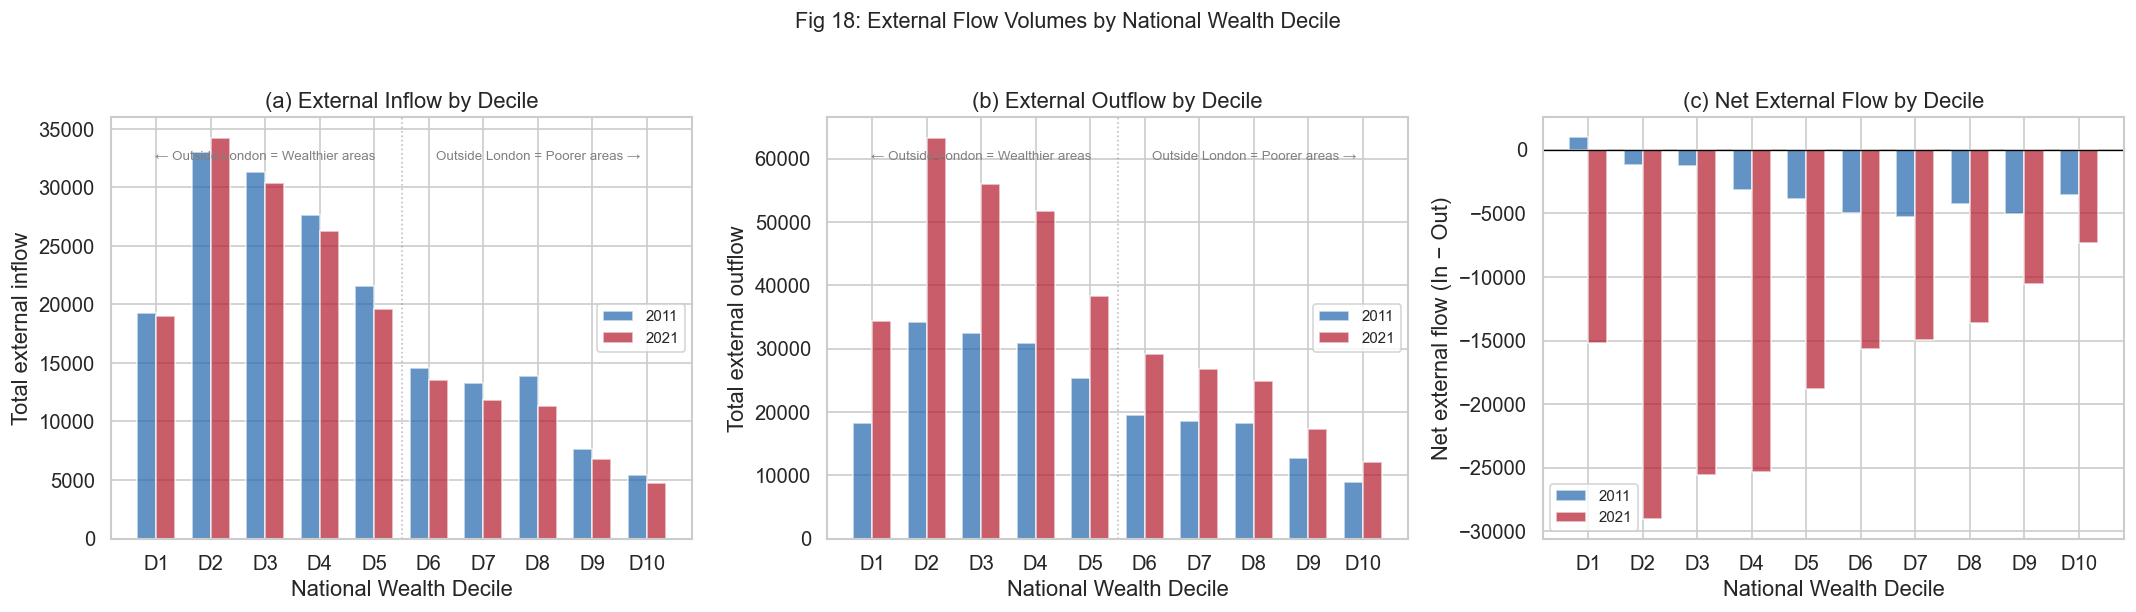

In [13]:
# ── Fig 18: External flow volumes by decile ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(1, 11)
w = 0.35

# Panel (a): External inflow by decile
ax = axes[0]
ax.bar(x - w/2, ext_dec['Ext_In_11'], w, label='2011', color='#2166ac', alpha=0.7)
ax.bar(x + w/2, ext_dec['Ext_In_21'], w, label='2021', color='#b2182b', alpha=0.7)
ax.set_xlabel('National Wealth Decile')
ax.set_ylabel('Total external inflow')
ax.set_title('(a) External Inflow by Decile')
ax.set_xticks(x)
ax.set_xticklabels([f'D{d}' for d in x])
ax.axvline(5.5, color='grey', ls=':', lw=1, alpha=0.5)
ax.text(3, ax.get_ylim()[1]*0.9, '← Outside London = Wealthier areas', ha='center', fontsize=8, color='grey')
ax.text(8, ax.get_ylim()[1]*0.9, 'Outside London = Poorer areas →', ha='center', fontsize=8, color='grey')
ax.legend(fontsize=9)

# Panel (b): External outflow by decile
ax = axes[1]
ax.bar(x - w/2, ext_dec['Ext_Out_11'], w, label='2011', color='#2166ac', alpha=0.7)
ax.bar(x + w/2, ext_dec['Ext_Out_21'], w, label='2021', color='#b2182b', alpha=0.7)
ax.set_xlabel('National Wealth Decile')
ax.set_ylabel('Total external outflow')
ax.set_title('(b) External Outflow by Decile')
ax.set_xticks(x)
ax.set_xticklabels([f'D{d}' for d in x])
ax.axvline(5.5, color='grey', ls=':', lw=1, alpha=0.5)
ax.text(3, ax.get_ylim()[1]*0.9, '← Outside London = Wealthier areas', ha='center', fontsize=8, color='grey')
ax.text(8, ax.get_ylim()[1]*0.9, 'Outside London = Poorer areas →', ha='center', fontsize=8, color='grey')
ax.legend(fontsize=9)

# Panel (c): Net external by decile
ax = axes[2]
ax.bar(x - w/2, ext_dec['Ext_Net_11'], w, label='2011', color='#2166ac', alpha=0.7)
ax.bar(x + w/2, ext_dec['Ext_Net_21'], w, label='2021', color='#b2182b', alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('National Wealth Decile')
ax.set_ylabel('Net external flow (In − Out)')
ax.set_title('(c) Net External Flow by Decile')
ax.set_xticks(x)
ax.set_xticklabels([f'D{d}' for d in x])
ax.legend(fontsize=9)

fig.suptitle('Fig 18: External Flow Volumes by National Wealth Decile', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_18_external_flows_by_decile.png', dpi=150)
plt.show()

### Fig 18 Interpretation

Both bar plots of external inflows and outflows are right skewed, meaning the majority of both external flows are interacted between more deprived London MSOAs and outside London areas.

But outflows from London to outside London increased significantly from 2011 to 2021, especially for London MSOAs in D2-D4. This showed more straightforward in the 3rd bar plot.

## 1d. Per-MSOA External Flow Intensity

How large are external flows relative to total migration? This determines how much leverage boundary effects have on each MSOA's cascade metrics.

In [14]:
# ── External share of total migration ─────────────────────────
for yr in ['11', '21']:
    ext_total = df[f'Ext_Inflow_nat_{yr}'] + df[f'Ext_Outflow_nat_{yr}']
    tmig = df[f'Total_Migration_nat_{yr}']
    df[f'Ext_Share_{yr}'] = np.where(tmig > 0, ext_total / tmig * 100, 0)

print('=== External flows as % of total migration ===')
for yr in ['11', '21']:
    col = f'Ext_Share_{yr}'
    print(f'\n  20{yr}:')
    print(f'    Mean:   {df[col].mean():.1f}%')
    print(f'    Median: {df[col].median():.1f}%')
    print(f'    P90:    {df[col].quantile(0.90):.1f}%')
    print(f'    Max:    {df[col].max():.1f}%')

=== External flows as % of total migration ===

  2011:
    Mean:   21.3%
    Median: 20.3%
    P90:    29.9%
    Max:    47.9%

  2021:
    Mean:   27.7%
    Median: 27.2%
    P90:    36.1%
    Max:    51.7%


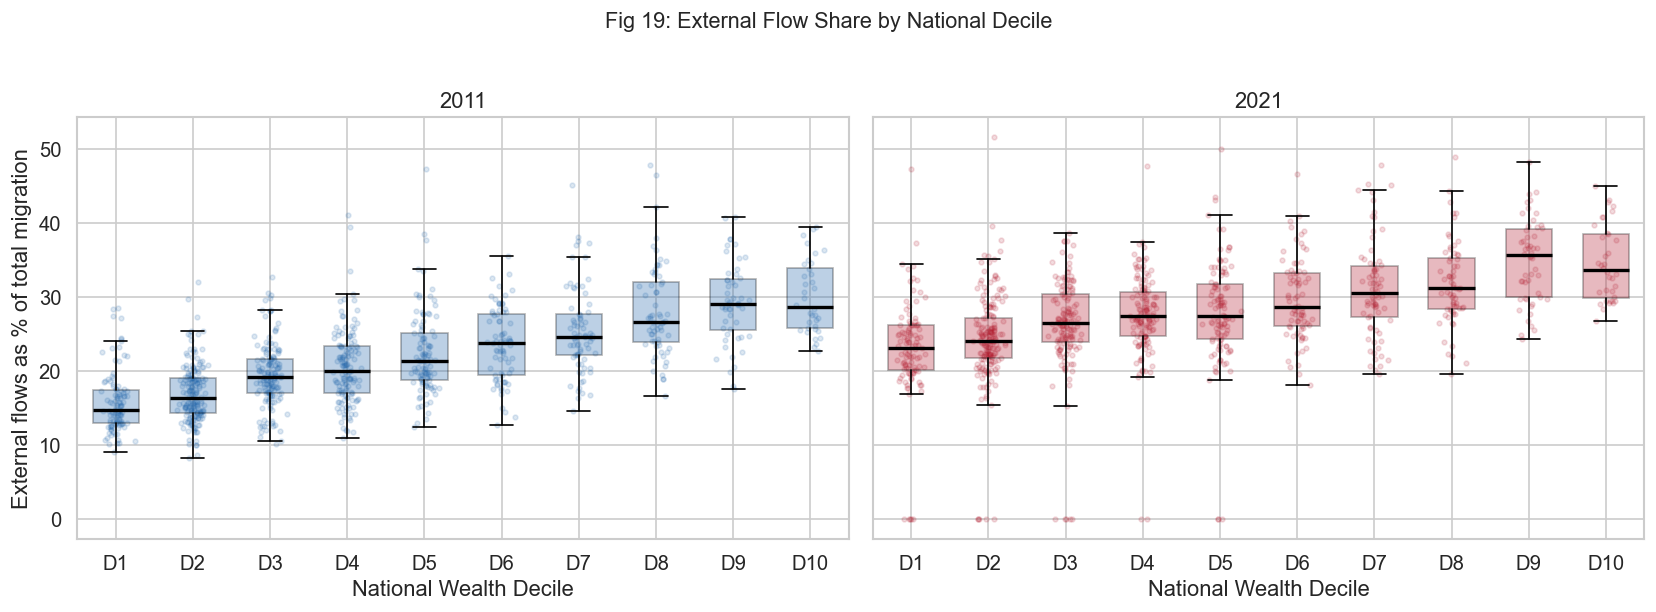

In [15]:
# ── Fig 19: External share by decile (box + strip) ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
dec_col = 'Wealth_Decile_National'

for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    col = f'Ext_Share_{yr}'
    
    data_by_dec = [df.loc[df[dec_col] == d, col].values for d in range(1, 11)]
    bp = ax.boxplot(data_by_dec, positions=range(1, 11), patch_artist=True,
                    widths=0.6, showfliers=False)
    for box in bp['boxes']:
        box.set_facecolor('#2166ac' if yr == '11' else '#b2182b')
        box.set_alpha(0.3)
    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(2)
    
    # Overlay strip
    for d in range(1, 11):
        vals = df.loc[df[dec_col] == d, col].values
        jitter = np.random.normal(0, 0.08, size=len(vals))
        ax.scatter(d + jitter, vals, alpha=0.15, s=8,
                   color='#2166ac' if yr == '11' else '#b2182b')
    
    ax.set_xlabel('National Wealth Decile')
    ax.set_title(f'20{yr}')
    ax.set_xticks(range(1, 11))
    ax.set_xticklabels([f'D{d}' for d in range(1, 11)])

axes[0].set_ylabel('External flows as % of total migration')
fig.suptitle('Fig 19: External Flow Share by National Decile', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_19_external_share_by_decile.png', dpi=150)
plt.show()

### Fig 19 Interpretation & external flow intensity results

The last cell results showed that there is increase in external flows from 2011 to 2021.

In fig 19:
- The overall trend increased (shift upward in general) from 2011 to 2021, consistent with the increase external flows.
- Compared with more steady increase in 2011, there is a small jump between D8 and D9 in 2021.
- Both D1 and D10 look keep the unchanged during the periods.

## 1e. How External Flows Feed Cascade vs Counter Directions

For MSOAs below D6 (the majority), external inflow = `Inflow_Wealthier` (cascade component), and external outflow = `Outflow_Wealthier` (counter-cascade component). So external flows inject volume into *both* sides of the cascade-counter balance. 

The key question is: is the injection symmetric?

In [17]:
# =====================================================================
# 1e: Three-way decomposition table
# =====================================================================

print('=' * 72)
print('THREE-WAY DECOMPOSITION: Reclassification vs External Flows')
print('=' * 72)
print('''
  A = London-internal flows, London-relative deciles  (original analysis)
  B = London-internal flows, NATIONAL deciles         (same flows, new ladder)
  C = London-internal + external flows, national deciles (full national frame)

  Reclassification effect = B − A   (switching the decile ladder)
  External flow effect    = C − B   (adding external flows)
  Total difference        = C − A   (what the old comparison showed)
''')

for yr in ['11', '21']:
    print(f'\n{"─" * 95}')
    print(f'  20{yr}')
    print(f'{"─" * 95}')
    print(f'{"Metric":>22s} {"Reclass (B−A)":>14s} {"External (C−B)":>15s} '
          f'{"Total (C−A)":>13s} {"% reclass":>11s} {"Ext/Reclass":>12s}')
    print('-' * 95)

    for col, label in [
        ('CFI_Churn',          'Cascade churn'),
        ('Counter_Churn',      'Counter churn'),
        ('Net_Cascade',        'Net cascade'),
        ('Net_Counter',        'Net counter'),
        ('Cascade_Dominance',  'Cascade dominance'),
    ]:
        a = df[f'{col}_{yr}'].sum() if 'Dominance' not in col else df[f'{col}_{yr}'].mean()
        b = df[f'{col}_intnat_{yr}'].sum() if 'Dominance' not in col else df[f'{col}_intnat_{yr}'].mean()
        c = df[f'{col}_nat_{yr}'].sum() if 'Dominance' not in col else df[f'{col}_nat_{yr}'].mean()

        reclass = b - a
        external = c - b
        total = c - a
        pct_reclass = (reclass / total * 100) if abs(total) > 0.001 else 0
        ratio = f'{abs(external) / abs(reclass):.1f}×' if abs(reclass) > 0.0001 else '—'

        if 'Dominance' in col:
            print(f'  {label:>20s}  {reclass:>+13.4f}  {external:>+14.4f}  '
                  f'{total:>+12.4f}  {pct_reclass:>9.1f}%  {ratio:>11s}')
        else:
            print(f'  {label:>20s}  {reclass:>+13,.0f}  {external:>+14,.0f}  '
                  f'{total:>+12,.0f}  {pct_reclass:>9.1f}%  {ratio:>11s}')

THREE-WAY DECOMPOSITION: Reclassification vs External Flows

  A = London-internal flows, London-relative deciles  (original analysis)
  B = London-internal flows, NATIONAL deciles         (same flows, new ladder)
  C = London-internal + external flows, national deciles (full national frame)

  Reclassification effect = B − A   (switching the decile ladder)
  External flow effect    = C − B   (adding external flows)
  Total difference        = C − A   (what the old comparison showed)


───────────────────────────────────────────────────────────────────────────────────────────────
  2011
───────────────────────────────────────────────────────────────────────────────────────────────
                Metric  Reclass (B−A)  External (C−B)   Total (C−A)   % reclass  Ext/Reclass
-----------------------------------------------------------------------------------------------
         Cascade churn        -26,970        +191,243      +164,273      -16.4%         7.1×
         Counter churn      

### Interpretation:

**London's internal hierarchy is more differentiated than the national one.**
- Reclassification of decile reference is negative for both churns.
    - London MSOAs crossing decile boundaries within London's own ladder do not always cross them nationally. 
    - Natioanlly, the boundaries are spaced further apart.
- This is a structural consequence of London skewing toward the deprived end of the national distribution.

**Reclassification of decile reference from London-only to national-framw is small, symmetric, and subtractive.**
- Switching from London-relative to national deciles reduces both cascade churn and counter churn by roughly similar amounts.
    - This is because London's internal deprivation gradient is steeper than the national one. When 983 London MSOAs are spread across ~6800 nationally, the decile boundaries widen, and some flows that crossed a London-specific boundary become same-decile under the national ladder.
- The effect is nearly symmetric between cascade and counter directions, so the impact of decile reclassification on `Cascade_Dominance` is negligible.
- **The choice of decile reference frame barely alters the balance between cascade and counter-cascade.** It just slightly deflates the absolute volumes on both sides.

**The assymetry between cascade and counter external boosts changes across census years.**
- In 2011, external flows pushed cascade (+191k) marginally harder than counter (+181k), nudging `Cascade_Dominance` upward by +0.0049.
- By 2021, counter (+278k) far outpaced cascade (+211k), pushing `Cascade_Dominance` downward by -0.009.
- **The counter external boost grew by 53% while the cascade boost grew by only 10% between periods.**
    - This asymmetry reflects the pandemic-era outflow surge.
    - **For the ~69% of London MSOAs sitting below national D6, leaving London for the D6 synthetic node is `Outflow_Wealthier`, a counter-cascade component.**
    - The doubling of external outflows between 2011 and 2021 injected volume disproportionately into the counter-cascade channel.

**External flows dominate the total difference.**
- External contributions are 6-12 times larger than reclassification changes in absolute terms for churn metrics.
- **These ratios widened from 2011 to 2021, which confirms that external flows became increasingly dominant between census periods, making the reclassification concern progressively less consequential to the findings.**
    - This is because the external outflows grew while reclassification effects stayed roughly constant.


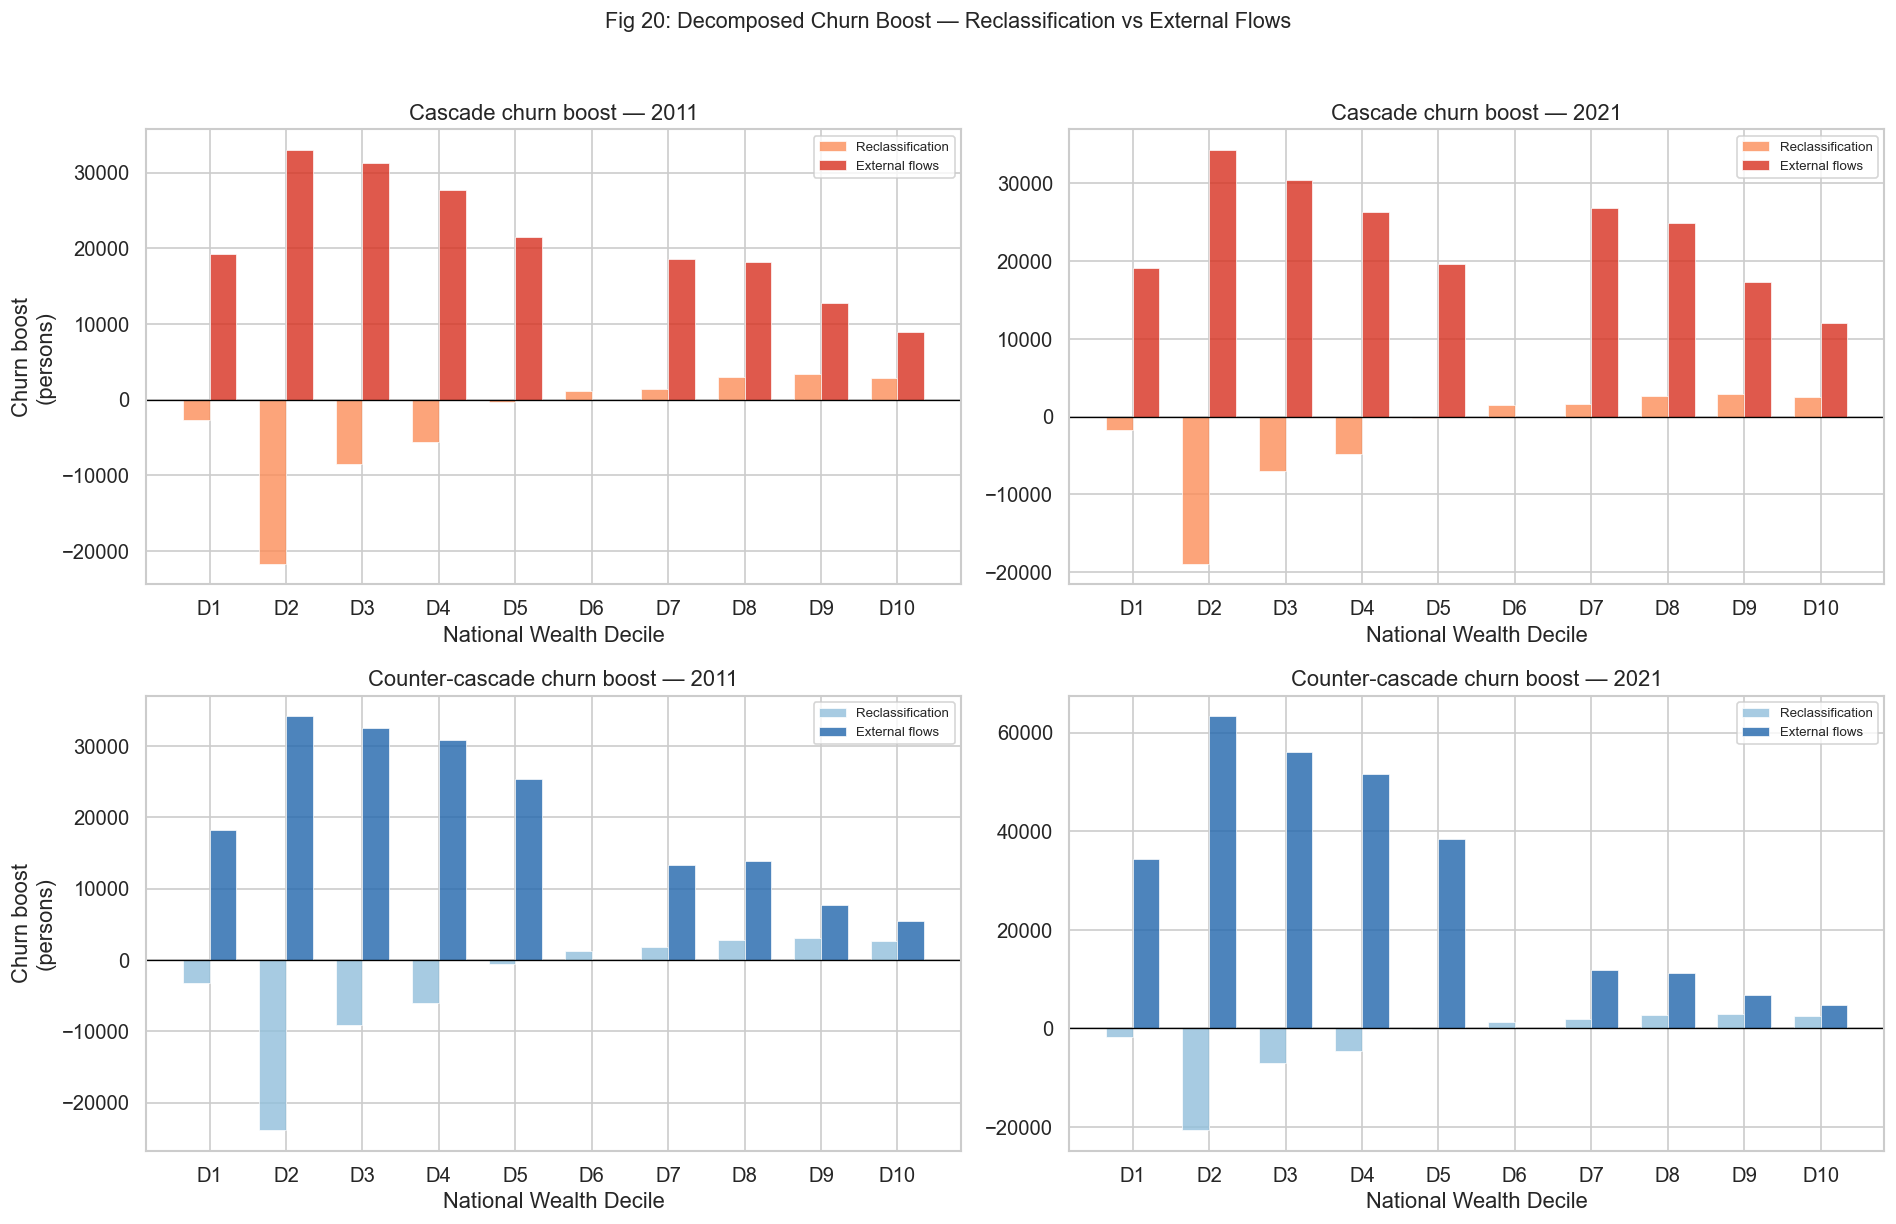

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = np.arange(1, 11)
w = 0.35

for row_idx, direction in enumerate(['cascade', 'counter']):
    for col_idx, yr in enumerate(['11', '21']):
        ax = axes[row_idx, col_idx]

        reclass_by_dec = []
        external_by_dec = []

        for d in range(1, 11):
            mask = df['Wealth_Decile_National'] == d

            if direction == 'cascade':
                a = (df.loc[mask, f'Inflow_Wealthier_{yr}'].sum() +
                     df.loc[mask, f'Outflow_Poorer_{yr}'].sum())
                b = (df.loc[mask, f'Inflow_Wealthier_intnat_{yr}'].sum() +
                     df.loc[mask, f'Outflow_Poorer_intnat_{yr}'].sum())
                c = (df.loc[mask, f'Inflow_Wealthier_nat_{yr}'].sum() +
                     df.loc[mask, f'Outflow_Poorer_nat_{yr}'].sum())
            else:
                a = (df.loc[mask, f'Outflow_Wealthier_{yr}'].sum() +
                     df.loc[mask, f'Inflow_Poorer_{yr}'].sum())
                b = (df.loc[mask, f'Outflow_Wealthier_intnat_{yr}'].sum() +
                     df.loc[mask, f'Inflow_Poorer_intnat_{yr}'].sum())
                c = (df.loc[mask, f'Outflow_Wealthier_nat_{yr}'].sum() +
                     df.loc[mask, f'Inflow_Poorer_nat_{yr}'].sum())

            reclass_by_dec.append(b - a)
            external_by_dec.append(c - b)

        # Side-by-side bars instead of stacked
        color_r = '#fc8d59' if direction == 'cascade' else '#91bfdb'
        color_e = '#d7301f' if direction == 'cascade' else '#2166ac'

        ax.bar(x - w/2, reclass_by_dec, w, label='Reclassification',
               color=color_r, alpha=0.8, edgecolor='white', lw=0.5)
        ax.bar(x + w/2, external_by_dec, w, label='External flows',
               color=color_e, alpha=0.8, edgecolor='white', lw=0.5)

        ax.axhline(0, color='black', lw=0.8)
        ax.set_xlabel('National Wealth Decile')
        ax.set_xticks(x)
        ax.set_xticklabels([f'D{d}' for d in x])

        title_dir = 'Cascade' if direction == 'cascade' else 'Counter-cascade'
        ax.set_title(f'{title_dir} churn boost — 20{yr}')
        if col_idx == 0:
            ax.set_ylabel('Churn boost\n(persons)')
        ax.legend(fontsize=8, loc='best')

fig.suptitle('Fig 20: Decomposed Churn Boost — Reclassification vs External Flows',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_20_decomposed_churn_boost.png', dpi=150)
plt.show()

### Fig 20 Interpretation 

(decomposed by different decile references and different flow systems)

Each bar is split into 2 components and each bar is the sum of 2 flow components. Both get fed by external flows:
1. Reclassification:
   
   The change caused by switching from within-London deciles to national deciles, while keeping exactly the same internal London flows.

   **This captures how boundary re-drawing of the decile ladder reclassifies moves that were previsouly lateral as cross-decile (or vice versa).**

2. External flows:

   The additional volume injected by including flows between London and outside London, under the same national decile system.


**Key Findings:**

**The structural pattern across all 4 panels.**
- External flows (dark bars) dminate the total boost everywhere except D6
- Reclassification (light bars) is small and concentrated in D1-D3

Reclassification is negative and concentrated at D1-D3. 
- The light bars dip below zero for the most deprived deciles in both years and for both cascade and counter directions.
    - This is because London's internal hierarchy is more compressed when mapping nationally.
    - Some cross-decile moves under within-London ladder become same-decile moves under the national ladder.
- The effects of shifting to same-decile moves is the strongest at D1-D3.
    - This is because D1-D3 is where the national compression is most severe.
    - London's D1-D5 maps onto national D1-D3, as shown in the repreprocessing file.

**Reclassification pattern is symmetric.**
- The reclassification pattern is nearly identical between cascade and counter rows.
- The classification deflates both sides equally and barely shifts the balance.

**D6 is near zero.**
- The synthetic external MSOA is assigned D6, so flows between a London D6 MSOA and outside London are lateral, as they're the same decile.
- No external cascade or counter volume is injected at D6. Any small bar at D6 is purely reclassification.
- This served as a built-in validation that the decomposition is working correctly.

**2011 has roughly balanced external injection.** (left-side)
- The dark cascade bars and dark counter bars are similar in magnitude across most deciles.
- This near-symmetry confirms that in 2011, London's external boundary was close to neutral for the cascade-counter balance.

**2021 has asymmetric emergence.** (right-side)
- The counter-cascade external bars are visibly taller than the cascade bars, particularly at D1-D5.
- **This widening gap between the 2 raws is what drived the city-wide `Cascade_Dominance` shift toward counter direction in 2021.**

---
# PART 2: What Shifts in the Cascade-Counter Balance?

In the part, all comparisons between London-only and national-frame are **under different decile classification systems**. 

These can be reagrded as **sensitivity analysis**, asking "how does the whole picture shift when we change the reference frame?"

All results are "switching from a London-relative to a national-relative frame changes these metrics by xxx, **reflecting both the reclassification and the inclusion of external flows**."

---

## 2a. Headline Comparison: London-only vs National Frame

In [ ]:
print('=' * 80)
print('HEADLINE METRIC COMPARISON: London-only vs National Frame')
print('=' * 80)

metrics_compare = [
    ('CFI_Churn', 'Cascade churn'),
    ('Counter_Churn', 'Counter churn'),
    ('Net_Cascade', 'Net cascade'),
    ('Net_Counter', 'Net counter'),
    ('Cascade_Dominance', 'Cascade dominance'),
]

for yr in ['11', '21']:
    print(f'\n── 20{yr} {"─" * 60}')
    print(f'{"Metric":>22s} {"London mean":>12s} {"National mean":>14s} {"Difference":>12s}')
    print('-' * 65)
    for col, label in metrics_compare:
        ldn = df[f'{col}_{yr}'].mean()
        nat = df[f'{col}_nat_{yr}'].mean()
        diff = nat - ldn
        print(f'  {label:>20s}  {ldn:>11.2f}  {nat:>13.2f}  {diff:>+11.2f}')

These numbers are consistene with the main findings - external flows nudge 

> **When we say metrics that are London related, we are talking them under the same decile hierarchy with national one, right?**

In [ ]:
# ── Aggregate sums (not just means) ──────────────────────────
print('\n' + '=' * 80)
print('AGGREGATE SUMS (city-wide totals)')
print('=' * 80)

sum_metrics = ['Net_Cascade', 'Net_Counter', 'CFI_Churn', 'Counter_Churn']
for yr in ['11', '21']:
    print(f'\n── 20{yr} ──')
    for m in sum_metrics:
        ldn = df[f'{m}_{yr}'].sum()
        nat = df[f'{m}_nat_{yr}'].sum()
        print(f'  {m:>20s}:  London={ldn:>12,.0f}   National={nat:>12,.0f}   '
              f'Boost={nat-ldn:>+10,.0f}')

## 2b. Cascade Dominance Shift: London-only → National

In [ ]:
# ── Per-MSOA dominance shift ──────────────────────────────────
for yr in ['11', '21']:
    df[f'Dom_Shift_{yr}'] = (df[f'Cascade_Dominance_nat_{yr}'] - 
                              df[f'Cascade_Dominance_{yr}'])

print('=== Cascade Dominance Shift (national − London-only) ===')
for yr in ['11', '21']:
    col = f'Dom_Shift_{yr}'
    print(f'\n  20{yr}:')
    print(f'    Mean shift:   {df[col].mean():+.6f}')
    print(f'    Median shift: {df[col].median():+.6f}')
    print(f'    Std:          {df[col].std():.6f}')
    toward_casc    = (df[col] > 0.001).sum()
    toward_counter = (df[col] < -0.001).sum()
    negligible     = len(df) - toward_casc - toward_counter
    print(f'    Shifted toward cascade:        {toward_casc} ({toward_casc/len(df)*100:.1f}%)')
    print(f'    Shifted toward counter:        {toward_counter} ({toward_counter/len(df)*100:.1f}%)')
    print(f'    Negligible change (±0.001):    {negligible} ({negligible/len(df)*100:.1f}%)')

In [ ]:
# ── Fig 19: Dominance shift by national decile ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
dec_col = 'Wealth_Decile_National'

for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    col = f'Dom_Shift_{yr}'
    
    means = df.groupby(dec_col)[col].mean()
    sems  = df.groupby(dec_col)[col].sem()
    
    color = '#2166ac' if yr == '11' else '#b2182b'
    ax.bar(means.index, means.values, color=color, alpha=0.6, 
           yerr=sems.values, capsize=3)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xlabel('National Wealth Decile')
    ax.set_title(f'20{yr}')
    ax.set_xticks(range(1, 11))
    ax.set_xticklabels([f'D{d}' for d in range(1, 11)])
    
    # Annotate direction
    ax.text(0.02, 0.95, '↑ Toward cascade', transform=ax.transAxes,
            fontsize=8, color='grey', va='top')
    ax.text(0.02, 0.05, '↓ Toward counter', transform=ax.transAxes,
            fontsize=8, color='grey', va='bottom')

axes[0].set_ylabel('Cascade Dominance shift\n(national − London-only)')
fig.suptitle('Fig 21: Cascade Dominance Shift by National Decile', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_21_dominance_shift_by_decile.png', dpi=150)
plt.show()

In [ ]:
# ── Fig 20: Per-MSOA dominance shift distribution ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    col = f'Dom_Shift_{yr}'
    color = '#2166ac' if yr == '11' else '#b2182b'
    
    ax.hist(df[col], bins=50, color=color, alpha=0.6, edgecolor='white', lw=0.3)
    ax.axvline(0, color='black', lw=1)
    ax.axvline(df[col].mean(), color=color, ls='--', lw=1.5,
               label=f'Mean: {df[col].mean():+.4f}')
    ax.axvline(df[col].median(), color=color, ls=':', lw=1.5,
               label=f'Median: {df[col].median():+.4f}')
    ax.set_xlabel('Dominance shift (national − London-only)')
    ax.set_title(f'20{yr}')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Number of MSOAs')
fig.suptitle('Fig 22: Distribution of Per-MSOA Cascade Dominance Shift', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_22_dominance_shift_distribution.png', dpi=150)
plt.show()

## 2c. Cross_Decile_Share Comparison

In [ ]:
print('=== Cross_Decile_Share: London-only vs National ===')
for yr in ['11', '21']:
    ldn = df[f'Cross_Decile_Share_{yr}']
    nat = df[f'Cross_Decile_Share_nat_{yr}']
    print(f'\n  20{yr}:')
    print(f'    London mean:   {ldn.mean():.4f}  (median {ldn.median():.4f})')
    print(f'    National mean: {nat.mean():.4f}  (median {nat.median():.4f})')
    print(f'    Difference:    {nat.mean() - ldn.mean():+.4f}')
    print(f'    Correlation:   {ldn.corr(nat):.4f}')

## 2d. Sign Concordance Comparison

In [ ]:
print('=== Sign Concordance: London-only vs National ===')
for yr in ['11', '21']:
    ldn = df[f'Sign_Concordance_{yr}']
    nat = df[f'Sign_Concordance_nat_{yr}']
    print(f'\n── 20{yr} ──')
    print(f'  London-only:')
    for v in ['concordant', 'divergent', 'zero']:
        n = (ldn == v).sum()
        print(f'    {v:>12s}: {n:>4d} ({n/len(df)*100:.1f}%)')
    print(f'  National frame:')
    for v in ['concordant', 'divergent', 'zero']:
        n = (nat == v).sum()
        print(f'    {v:>12s}: {n:>4d} ({n/len(df)*100:.1f}%)')
    
    # Cross-tab
    print(f'\n  Cross-tab (rows=London, cols=National):')
    ct = pd.crosstab(ldn, nat)
    print(ct.to_string())
    changed = (ldn != nat).sum()
    print(f'  Changed classification: {changed} ({changed/len(df)*100:.1f}%)')

---
# PART 3: Does the Typology Change?

### Important methodological note

The national-frame metrics (`_nat_`) differ from London-only metrics in **two confounded ways**:
1. **Different decile frame**: London-only assigns deciles among 983 London MSOAs; national assigns among ~6,800 England MSOAs. Because London skews deprived nationally (~69% fall in national D1–D5), a London-only D5 might be national D3. Only 23.5% of MSOAs keep the same decile number in both frames.
2. **External flows added**: The +1 synthetic MSOA injects additional migration volume.

These two effects cannot be cleanly separated in the current data. A high typology switch rate therefore reflects **both** the re-framing of what counts as "cross-decile" **and** the additional external flows. This is by design — the national frame is a holistic sensitivity test — but it means typology switches should not be interpreted as purely an "external flow" effect.

---

## 3a. Typology Assignment: National Frame

Using the same thresholds as EDA 3:
- `Cascade_Dominance` > 0.52 → Cascade-led
- `Cascade_Dominance` < 0.48 → Counter-led
- Between 0.48 and 0.52 → Symmetric
- `Cross_Decile_Share` < P25 → Lateral

In [ ]:
def assign_typology(dom, cds, dom_upper=0.52, dom_lower=0.48, cds_threshold=None):
    """Classify MSOA into flow regime typology."""
    if cds < cds_threshold:
        return 'Lateral'
    elif dom > dom_upper:
        return 'Cascade-led'
    elif dom < dom_lower:
        return 'Counter-led'
    else:
        return 'Symmetric'

# ── London-only typology (same as EDA 3) ──────────────────────
for yr in ['11', '21']:
    cds_p25 = df[f'Cross_Decile_Share_{yr}'].quantile(0.25)
    df[f'Typology_{yr}'] = [
        assign_typology(dom, cds, cds_threshold=cds_p25)
        for dom, cds in zip(df[f'Cascade_Dominance_{yr}'], 
                            df[f'Cross_Decile_Share_{yr}'])
    ]

# ── National-frame typology ───────────────────────────────────
for yr in ['11', '21']:
    cds_p25_nat = df[f'Cross_Decile_Share_nat_{yr}'].quantile(0.25)
    df[f'Typology_nat_{yr}'] = [
        assign_typology(dom, cds, cds_threshold=cds_p25_nat)
        for dom, cds in zip(df[f'Cascade_Dominance_nat_{yr}'], 
                            df[f'Cross_Decile_Share_nat_{yr}'])
    ]
    print(f'Cross_Decile_Share P25 (20{yr}): London={df[f"Cross_Decile_Share_{yr}"].quantile(0.25):.4f}, '
          f'National={cds_p25_nat:.4f}')

print('\n=== Typology Counts ===')
order = ['Cascade-led', 'Symmetric', 'Counter-led', 'Lateral']
for yr in ['11', '21']:
    print(f'\n── 20{yr} ──')
    print(f'{"Type":>14s} {"London":>8s} {"National":>10s} {"Change":>8s}')
    for t in order:
        n_ldn = (df[f'Typology_{yr}'] == t).sum()
        n_nat = (df[f'Typology_nat_{yr}'] == t).sum()
        print(f'  {t:>12s}  {n_ldn:>6d}  {n_nat:>8d}  {n_nat - n_ldn:>+6d}')

## 3b. Typology Cross-Tabulation: Which MSOAs Switch?

In [ ]:
for yr in ['11', '21']:
    print(f'\n{"=" * 60}')
    print(f'TYPOLOGY CROSS-TAB: 20{yr} (rows=London, cols=National)')
    print(f'{"=" * 60}')
    ct = pd.crosstab(df[f'Typology_{yr}'], df[f'Typology_nat_{yr}'],
                     margins=True, margins_name='Total')
    ct = ct.reindex(index=order + ['Total'], columns=order + ['Total'], fill_value=0)
    print(ct.to_string())
    
    same  = (df[f'Typology_{yr}'] == df[f'Typology_nat_{yr}']).sum()
    diff  = len(df) - same
    print(f'\n  Unchanged: {same} ({same/len(df)*100:.1f}%)')
    print(f'  Changed:   {diff} ({diff/len(df)*100:.1f}%)')

## 3c. Who Switches? Profile by Decile and Borough

### 3c-i. Decomposing the Confound: Decile Frame vs External Flows

To understand how much of the typology switching is driven by decile re-framing versus external flows, we check whether MSOAs that changed national decile are more likely to switch typology.

In [ ]:
# ── Confound decomposition: decile-frame vs external-flow effect ──
yr = '21'
df['Same_Decile'] = df['Wealth_Decile'] == df['Wealth_Decile_National']
switched = df[f'Typology_{yr}'] != df[f'Typology_nat_{yr}']

same_dec = df['Same_Decile']
diff_dec = ~df['Same_Decile']

print('=== Confound Decomposition (2021): Decile Frame vs External Flows ===')
print(f'\n  MSOAs that KEPT the same decile number in both frames:')
n_same = same_dec.sum()
n_sw_same = (same_dec & switched).sum()
print(f'    N = {n_same} ({n_same/len(df)*100:.1f}% of all MSOAs)')
print(f'    Typology switched: {n_sw_same} ({n_sw_same/n_same*100:.1f}% of this group)')
print(f'    → These switches are driven ONLY by external-flow effects')
print(f'       (since their decile frame didn\'t change)')

print(f'\n  MSOAs that CHANGED decile between frames:')
n_diff = diff_dec.sum()
n_sw_diff = (diff_dec & switched).sum()
print(f'    N = {n_diff} ({n_diff/len(df)*100:.1f}% of all MSOAs)')
print(f'    Typology switched: {n_sw_diff} ({n_sw_diff/n_diff*100:.1f}% of this group)')
print(f'    → These switches reflect BOTH decile re-framing AND external flows')

print(f'\n  Comparison:')
print(f'    Switch rate if decile unchanged:  {n_sw_same/n_same*100:.1f}%')
print(f'    Switch rate if decile changed:    {n_sw_diff/n_diff*100:.1f}%')
print(f'    ⟹ Decile re-framing approximately {"doubles" if n_sw_diff/n_diff > 1.5*(n_sw_same/n_same) else "increases"} '
      f'the switch rate')
print(f'\n  Attribution (rough):')
print(f'    Switches from external-flow effect alone:  ~{n_sw_same}')
print(f'    Additional switches from decile re-framing: ~{n_sw_diff - int(n_diff * n_sw_same/n_same)}')
print(f'    (Estimated by applying the same-decile switch rate to the changed-decile group)')

In [ ]:
# ── Switchers by decile ───────────────────────────────────────
for yr in ['21']:  # Focus on 2021 (the key period)
    switched = df[f'Typology_{yr}'] != df[f'Typology_nat_{yr}']
    df[f'Switched_{yr}'] = switched
    
    print(f'\n=== 20{yr} Switchers by National Decile ===')
    print(f'{"Decile":>8s} {"N_total":>8s} {"N_switched":>10s} {"% switched":>10s}')
    for d in range(1, 11):
        mask = df['Wealth_Decile_National'] == d
        n_total = mask.sum()
        n_sw = (mask & switched).sum()
        pct = n_sw / n_total * 100 if n_total > 0 else 0
        print(f'  D{d:>2d}    {n_total:>6d}    {n_sw:>8d}    {pct:>8.1f}%')
    
    print(f'\n=== 20{yr} Top 10 Boroughs by Switch Count ===')
    borough_switches = (df.loc[switched, 'ladnm']
                        .value_counts().head(10))
    for boro, count in borough_switches.items():
        total_in_boro = (df['ladnm'] == boro).sum()
        print(f'  {boro:>30s}: {count:>3d} / {total_in_boro} '
              f'({count/total_in_boro*100:.0f}%)')

In [ ]:
# ── Transition detail for 2021 ────────────────────────────────
yr = '21'
switched_mask = df[f'Switched_{yr}']

print(f'\n=== 20{yr} Transition Detail ===')
transitions = (df.loc[switched_mask]
               .groupby([f'Typology_{yr}', f'Typology_nat_{yr}'])
               .size().reset_index(name='count')
               .sort_values('count', ascending=False))
transitions.columns = ['From (London)', 'To (National)', 'N']
print(transitions.to_string(index=False))

## 3d. Typology Scatter: London-only vs National (2021)

In [ ]:
TYPOLOGY_COLORS = {
    'Cascade-led':  '#d6604d',
    'Symmetric':    '#66c2a5',
    'Counter-led':  '#8073ac',
    'Lateral':      '#bdbdbd'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

yr = '21'
configs = [
    (f'Cascade_Dominance_{yr}', f'Cross_Decile_Share_{yr}', 
     f'Typology_{yr}', 'London-only frame'),
    (f'Cascade_Dominance_nat_{yr}', f'Cross_Decile_Share_nat_{yr}', 
     f'Typology_nat_{yr}', 'National frame'),
]

for idx, (x_col, y_col, typ_col, title) in enumerate(configs):
    ax = axes[idx]
    for t in order:
        mask = df[typ_col] == t
        ax.scatter(df.loc[mask, x_col], df.loc[mask, y_col],
                   c=TYPOLOGY_COLORS[t], label=t, alpha=0.5, s=15, edgecolors='none')
    
    ax.axvline(0.50, color='grey', ls=':', lw=0.8, alpha=0.5)
    ax.axvline(0.52, color='black', ls='--', lw=0.8, alpha=0.5)
    ax.axvline(0.48, color='black', ls='--', lw=0.8, alpha=0.5)
    
    cds_p25 = df[y_col].quantile(0.25)
    ax.axhline(cds_p25, color='black', ls='--', lw=0.8, alpha=0.5)
    
    ax.set_xlabel('Cascade Dominance')
    ax.set_ylabel('Cross Decile Share')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')
    
    # Count annotation
    counts = df[typ_col].value_counts()
    text = '\n'.join([f'{t}: {counts.get(t, 0)}' for t in order])
    ax.text(0.02, 0.98, text, transform=ax.transAxes, fontsize=8,
            va='top', ha='left', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle(f'Fig 23: Typology Scatter — London-only vs National Frame (20{yr})', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'fig_23_typology_scatter_comparison_{yr}.png', dpi=150)
plt.show()

## 3e. IMD Validation: Does National-Frame Typology Predict IMD Change Better?

In [ ]:
yr = '21'
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (typ_col, title) in enumerate([
    (f'Typology_{yr}', 'London-only frame'),
    (f'Typology_nat_{yr}', 'National frame'),
]):
    ax = axes[idx]
    data = [df.loc[df[typ_col] == t, 'IMD_Pctile_Change'].dropna().values
            for t in order]
    bp = ax.boxplot(data, positions=range(len(order)), patch_artist=True, widths=0.6)
    for i, box in enumerate(bp['boxes']):
        box.set_facecolor(TYPOLOGY_COLORS[order[i]])
        box.set_alpha(0.6)
    for med in bp['medians']:
        med.set_color('black')
        med.set_linewidth(2)
    
    ax.set_xticklabels(order, fontsize=9, rotation=15)
    ax.set_ylabel('IMD Pctile Change')
    ax.set_title(title)
    
    # Kruskal-Wallis
    valid_data = [g for g in data if len(g) > 0]
    if len(valid_data) > 1:
        kw_stat, kw_p = stats.kruskal(*valid_data)
        ax.annotate(f'H = {kw_stat:.1f}, p = {kw_p:.2e}',
                    xy=(0.98, 0.02), xycoords='axes fraction', ha='right', fontsize=9,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle(f'Fig 24: IMD Validation — London-only vs National Frame (20{yr})', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'fig_24_imd_validation_comparison_{yr}.png', dpi=150)
plt.show()

In [ ]:
# ── Correlation comparison ────────────────────────────────────
yr = '21'
print(f'=== Cascade metric correlations with IMD_Pctile_Change (20{yr}) ===')
print(f'{"Metric":>28s} {"London r":>10s} {"National r":>12s} {"Diff":>8s}')
print('-' * 62)

for m in ['Cascade_Dominance', 'Cross_Decile_Share', 'Net_Cascade', 'CFI_Churn']:
    ldn_col = f'{m}_{yr}'
    nat_col = f'{m}_nat_{yr}'
    if ldn_col in df.columns and nat_col in df.columns:
        r_ldn = df[ldn_col].corr(df['IMD_Pctile_Change'])
        r_nat = df[nat_col].corr(df['IMD_Pctile_Change'])
        print(f'  {m:>26s}  {r_ldn:>+8.4f}    {r_nat:>+8.4f}  {r_nat - r_ldn:>+8.4f}')

---
# Summary

---

In [ ]:
print('=' * 72)
print('EDA 4 — BOUNDARY EFFECTS SUMMARY')
print('=' * 72)

print('''
PART 1 — Where External Flows Land
──────────────────────────────────────────────
• External MSOA assigned D6; 69% of London MSOAs sit below D6 nationally,
  so for most MSOAs, external connections are "wealthier".
• External inflows were stable (188k → 178k), but outflows nearly doubled
  (219k → 354k). London became a much stronger net exporter by 2021.
• External flows inject volume into BOTH cascade and counter directions
  (wealthier inflow = cascade; wealthier outflow = counter).
  The asymmetry between the two injections determines the net effect.
''')

dom_shift_11 = df['Dom_Shift_11'].mean()
dom_shift_21 = df['Dom_Shift_21'].mean()

print(f'''
PART 2 — Cascade-Counter Balance Shift
──────────────────────────────────────────────
• 2011: External flows nudge dominance toward CASCADE by {dom_shift_11:+.4f}.
  Inflow and outflow boosts were roughly balanced.
• 2021: External flows nudge dominance toward COUNTER by {dom_shift_21:+.4f}.
  The outflow surge (pandemic-era "flight from London") fed counter-cascade
  disproportionately, because for D1–D5 MSOAs, leaving for D6 areas is
  "Outflow_Wealthier" — a counter-cascade component.
• The boundary effect reversed direction between census periods.
''')

yr = '21'
same = (df[f'Typology_{yr}'] == df[f'Typology_nat_{yr}']).sum()
diff = len(df) - same

print(f'''
PART 3 — Typology Stability
──────────────────────────────────────────────
• 2021: {same} MSOAs ({same/len(df)*100:.1f}%) retained their typology classification.
        {diff} MSOAs ({diff/len(df)*100:.1f}%) switched.
• The core narrative holds: counter-cascade dominance intensifying between
  censuses is reinforced, not undermined, by boundary effects.
• London-only analysis UNDERSTATES the counter-cascade shift in 2021.
''')